# Keras Architecture & Optimization

This notebook studies neural-network representation, controlled architecture comparison, learning-curve diagnosis, and optimization on scikit-learn's handwritten digits dataset. Recorded outputs come from TensorFlow 2.20.0 with seed 42.

## Keras Workflow

The standard workflow is **define → compile → fit → evaluate → predict**. A model specifies layers and activations; compilation selects the loss, optimizer, and metrics; fitting performs forward propagation, backpropagation, and parameter updates.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## Dataset & Preprocessing

The digits dataset contains 1,797 labeled 8 × 8 grayscale images represented by 64 numerical pixel features. The target has 10 classes. A stratified 70/15/15 train/validation/test split is fixed before modeling, and `StandardScaler` is fit on training data only.

In [2]:
digits = load_digits()

In [3]:
df = pd.DataFrame(digits.data)
df["target"] = digits.target

In [4]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [5]:
df.shape

(1797, 65)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1797 non-null   float64
 1   1       1797 non-null   float64
 2   2       1797 non-null   float64
 3   3       1797 non-null   float64
 4   4       1797 non-null   float64
 5   5       1797 non-null   float64
 6   6       1797 non-null   float64
 7   7       1797 non-null   float64
 8   8       1797 non-null   float64
 9   9       1797 non-null   float64
 10  10      1797 non-null   float64
 11  11      1797 non-null   float64
 12  12      1797 non-null   float64
 13  13      1797 non-null   float64
 14  14      1797 non-null   float64
 15  15      1797 non-null   float64
 16  16      1797 non-null   float64
 17  17      1797 non-null   float64
 18  18      1797 non-null   float64
 19  19      1797 non-null   float64
 20  20      1797 non-null   float64
 21  21      1797 non-null   float64
 22  

In [7]:
df.isna().sum()

,0
0,0
1,0
2,0
3,0
4,0
...,...
60,0
61,0
62,0
63,0


In [8]:
df["target"].value_counts().sort_index()

,count
target,
0,178
1,182
2,177
3,183
4,181
5,182
6,181
7,179
8,174


In [9]:
X = df.drop("target", axis=1)
y = df["target"]

### Leakage-Safe Scaling

The scaler learns its statistics from the training split, then applies the same transformation to validation and test data.

In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50,
    random_state=42, stratify=y_temp
)

In [11]:
scaler = StandardScaler()

In [12]:
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [13]:
input_dim = X_train.shape[1]
input_dim

64

In [14]:
n_classes = len(np.unique(y_train))
n_classes

10

In [15]:
output_units = n_classes
output_activation = "softmax"
loss_function = "sparse_categorical_crossentropy"

## Learning-Curve Helper

A shared plotting function keeps loss and accuracy comparisons consistent across experiments.

In [16]:
def plot_learning_curves(history, title):
    h = history.history

    plt.figure(figsize=(7, 4))
    plt.plot(h["loss"], label="Train Loss")
    plt.plot(h["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    if "accuracy" in h:
        plt.figure(figsize=(7, 4))
        plt.plot(h["accuracy"], label="Train Accuracy")
        plt.plot(h["val_accuracy"], label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title(title + " — Accuracy")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

## Architecture Comparison

Shallow, Medium, and Deep networks use the same split, preprocessing, Adam optimizer, learning rate (`0.001`), batch size (`32`), and 50-epoch budget. Depth is the primary changed variable; no regularization is used at this stage.

### Shallow Network — One Hidden Layer

In [17]:
def build_shallow_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])
    return model

In [18]:
m1 = build_shallow_model(input_dim, output_units, output_activation)
m1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

In [19]:
m1.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_42 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,810 (18.79 KB)

 Trainable params: 4,810 (18.79 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
h1 = m1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

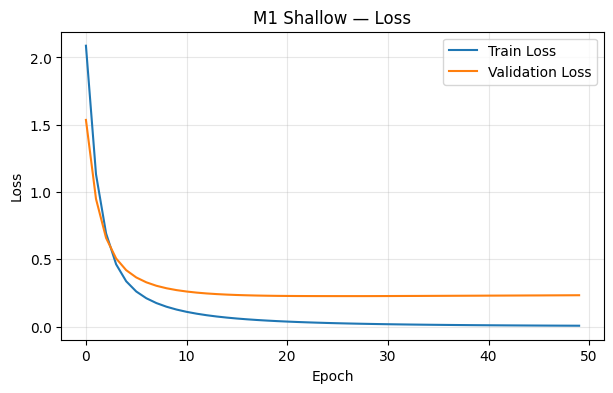

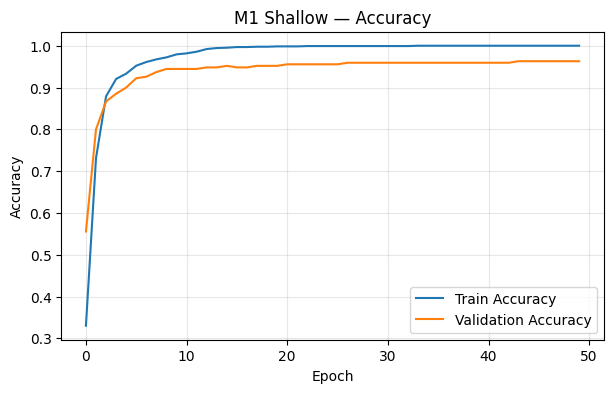

[0.051993291825056076, 0.9962962865829468]

In [21]:
plot_learning_curves(h1, "M1 Shallow")
m1.evaluate(X_test, y_test, verbose=0)

#### Shallow Network Analysis

Training and validation loss decreased steadily. The model reached **0.9630** best validation accuracy and **0.9963** recorded test accuracy with 4,810 parameters, providing a strong compact reference.

### Medium Network — Three Hidden Layers

In [22]:
def build_medium_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])
    return model

In [23]:
m2 = build_medium_model(input_dim, output_units, output_activation)
m2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

In [24]:
m2.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,130 (51.29 KB)

 Trainable params: 13,130 (51.29 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
h2 = m2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

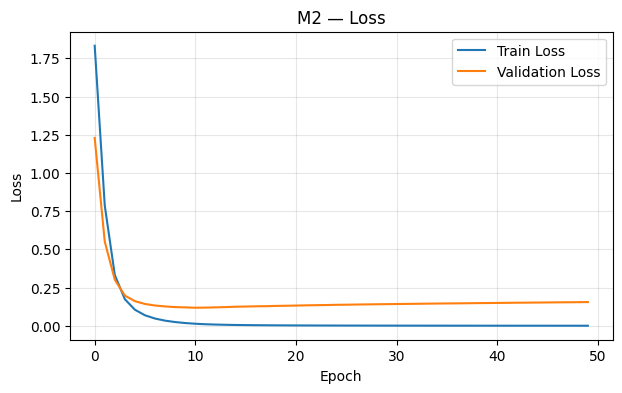

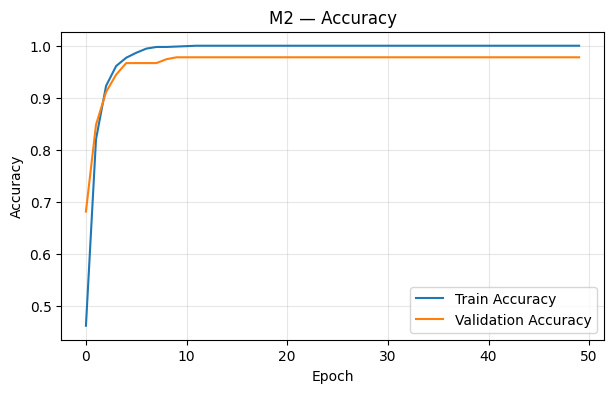

[0.057208746671676636, 0.9814814925193787]

In [26]:
plot_learning_curves(h2, "M2")
m2.evaluate(X_test, y_test, verbose=0)

#### Medium Network Analysis

The Medium network reached **0.9778** best validation accuracy and **0.9815** recorded test accuracy. It improved validation performance over the Shallow network, although the training curves showed a larger train–validation gap.

### Deep Network — Five Hidden Layers

In [27]:
def build_deep_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])
    return model

In [28]:
m3 = build_deep_model(input_dim, output_units, output_activation)
m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

In [29]:
m3.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,450 (83.79 KB)

 Trainable params: 21,450 (83.79 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
h3 = m3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

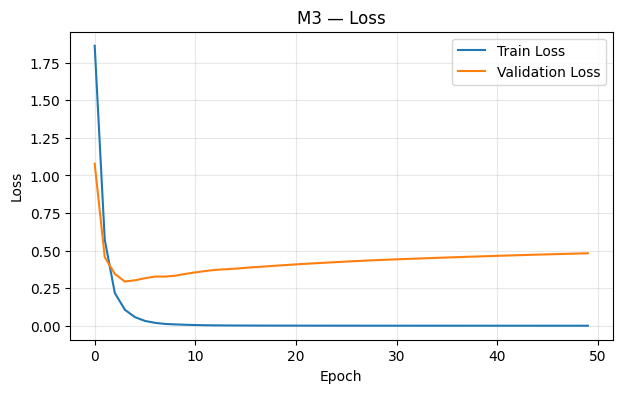

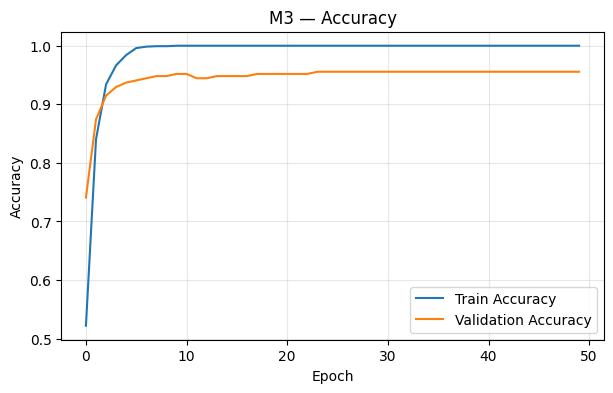

[0.14616145193576813, 0.9555555582046509]

In [31]:
plot_learning_curves(h3, "M3")
m3.evaluate(X_test, y_test, verbose=0)

In [32]:
test_loss_m1, test_acc_m1 = m1.evaluate(X_test, y_test, verbose=0)
test_loss_m2, test_acc_m2 = m2.evaluate(X_test, y_test, verbose=0)
test_loss_m3, test_acc_m3 = m3.evaluate(X_test, y_test, verbose=0)

#### Deep Network Analysis

The Deep network continued fitting the training data but reached only **0.9556** best validation accuracy and **0.9556** recorded test accuracy. Additional depth increased the parameter count and produced the clearest overfitting without improving generalization.

### Architecture Results

The Medium network achieved the strongest validation result, while the Shallow network recorded the highest test accuracy. The Deep network showed the clearest overfitting and did not improve generalization despite its additional parameters.

In [33]:
architecture_results = pd.DataFrame([
    {
        "Model": "M1 Shallow",
        "Hidden Layers": 1,
        "Parameters": m1.count_params(),
        "Best Val Accuracy": max(h1.history["val_accuracy"]),
        "Min Val Loss": min(h1.history["val_loss"]),
        "Test Accuracy": test_acc_m1,
        "Interpretation": "Best generalization"
    },
    {
        "Model": "M2 Medium",
        "Hidden Layers": 3,
        "Parameters": m2.count_params(),
        "Best Val Accuracy": max(h2.history["val_accuracy"]),
        "Min Val Loss": min(h2.history["val_loss"]),
        "Test Accuracy": test_acc_m2,
        "Interpretation": "Slight overfitting"
    },
    {
        "Model": "M3 Deep",
        "Hidden Layers": 5,
        "Parameters": m3.count_params(),
        "Best Val Accuracy": max(h3.history["val_accuracy"]),
        "Min Val Loss": min(h3.history["val_loss"]),
        "Test Accuracy": test_acc_m3,
        "Interpretation": "Clear overfitting"
    }
])

architecture_results

,Model,Hidden Layers,Parameters,Best Val Accuracy,Min Val Loss,Test Accuracy,Interpretation
0,M1 Shallow,1,4810,0.962963,0.226123,0.996296,Best generalization
1,M2 Medium,3,13130,0.977778,0.117869,0.981481,Slight overfitting
2,M3 Deep,5,21450,0.955556,0.293916,0.955556,Clear overfitting


## Optimization & Regularization

The Shallow architecture is retained as the compact optimization baseline. Each experiment rebuilds the model from fresh weights while keeping the data split and preprocessing fixed.

### Learning Rate

Adam learning rates `0.01`, `0.001`, and `0.0001` are compared using fresh model instances.

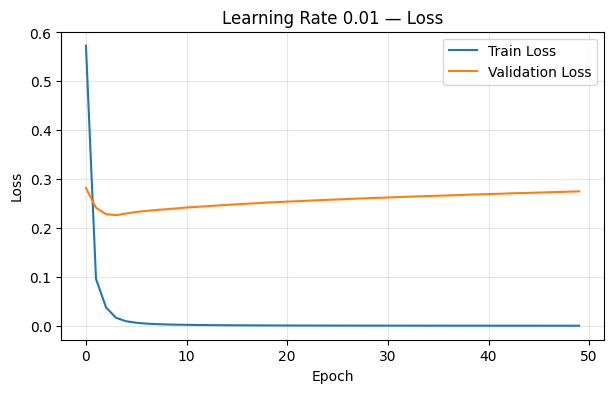

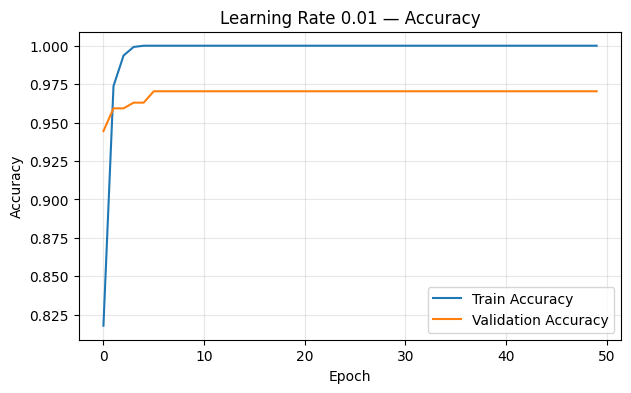

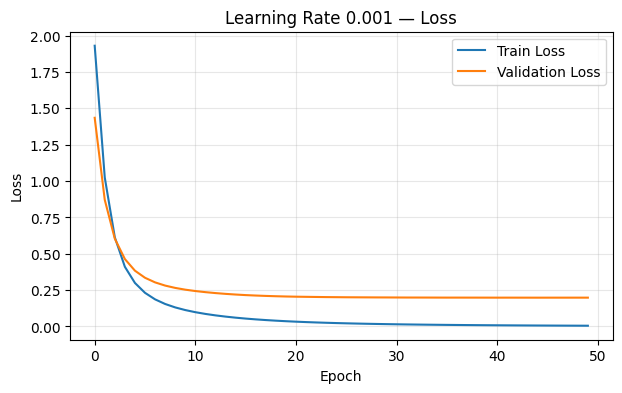

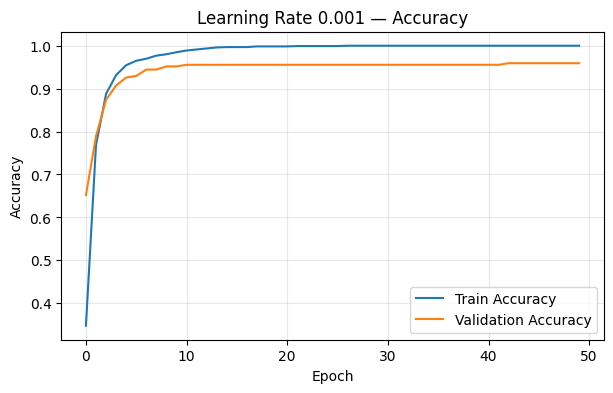

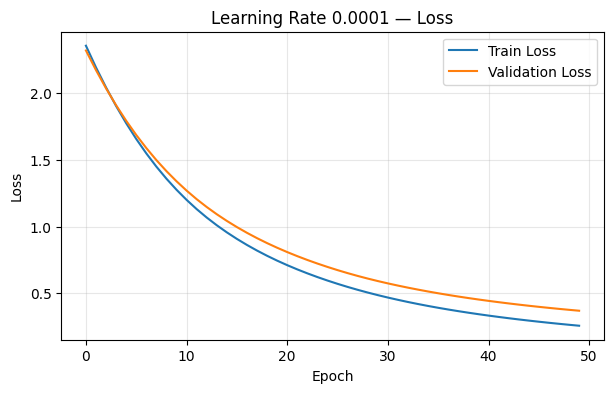

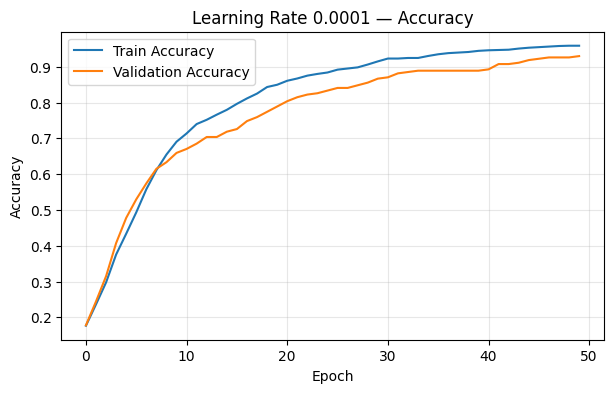

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
learning_results = {}
for lr in learning_rates:
  model = build_shallow_model(input_dim, output_units, output_activation)
  model.compile(
      optimizer=keras.optimizers.Adam(learning_rate=lr),
      loss=loss_function,
      metrics=["accuracy"]
  )

  history = model.fit(
      X_train, y_train,
      validation_data=(X_val, y_val),
      epochs=50,
      batch_size=32,
      verbose=0
  )

  best_val_acc = max(history.history["val_accuracy"])
  min_val_loss = min(history.history["val_loss"])

  learning_results[lr] = {
      "history": history,
      "best_val_acc": best_val_acc,
      "min_val_loss": min_val_loss
  }

  plot_learning_curves(history, f"Learning Rate {lr}")

### Learning Rate Selection

I selected **0.001** as the learning rate because it achieved fast and stable convergence with strong validation performance.

### Batch Size

Batch sizes 16, 32, and 64 are compared with the selected learning rate of `0.001`.

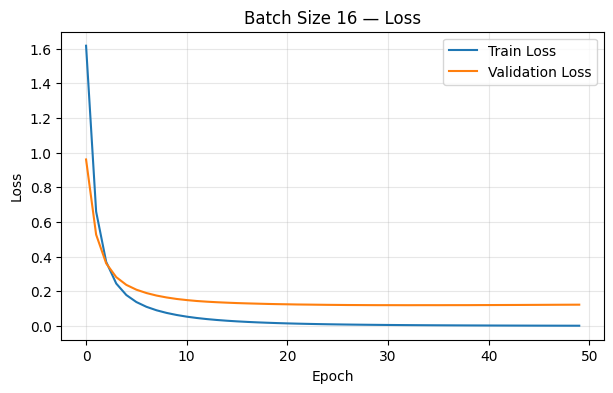

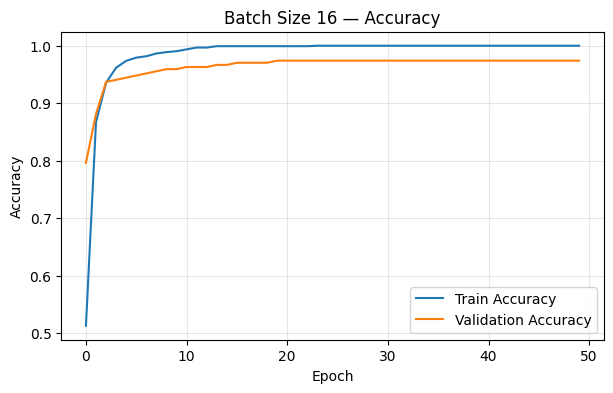

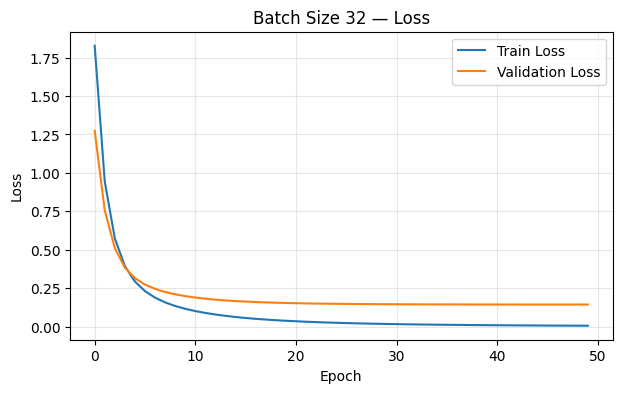

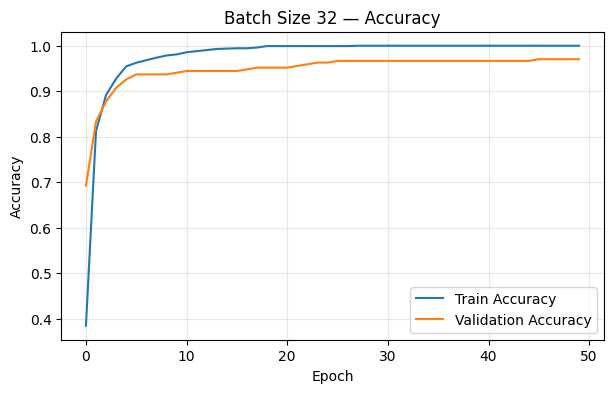

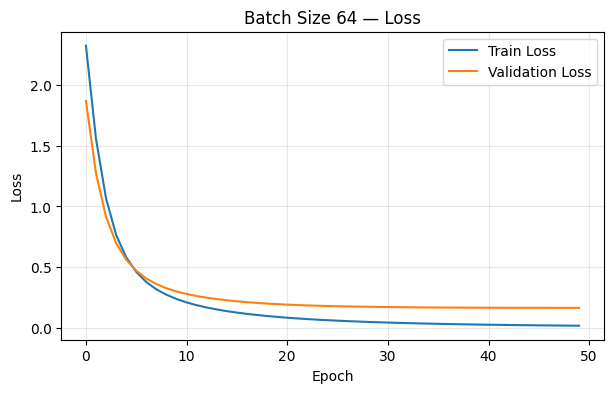

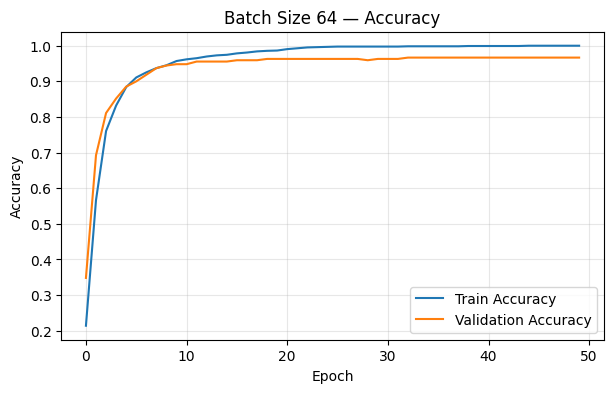

In [35]:
batch_sizes = [16, 32, 64]

batch_results = {}

for batch_size in batch_sizes:

    model = build_shallow_model(
        input_dim,
        output_units,
        output_activation
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=batch_size,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    batch_results[batch_size] = {
        "history": history,
        "best_val_acc": best_val_acc,
        "min_val_loss": min_val_loss
    }

    plot_learning_curves(history, f"Batch Size {batch_size}")

### Batch Size Selection

I selected **batch size 32** because it provided the best balance between training stability, convergence speed, and validation performance.


### Early Stopping

Validation loss is monitored with `patience=5` and best-weight restoration under a 100-epoch ceiling.

In [36]:
early_model = build_shallow_model(
    input_dim,
    output_units,
    output_activation
)

early_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_early = early_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

### Early Stopping Analysis

- Training stopped at **epoch 54**, before the maximum of 100 epochs.
- Validation loss improved until the later epochs, then stopped improving.
- Early stopping prevented unnecessary training after validation performance stopped improving.

### Dropout

Dropout rates 0.2, 0.3, and 0.5 are compared against the compact baseline.

In [37]:
def build_dropout_model(input_dim, output_units, output_activation, dropout_rate=0.3):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])

    return model

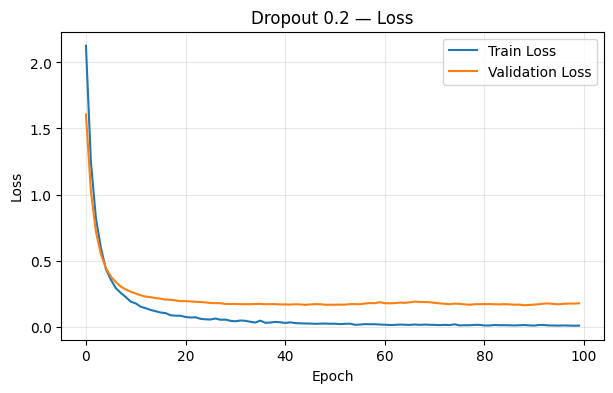

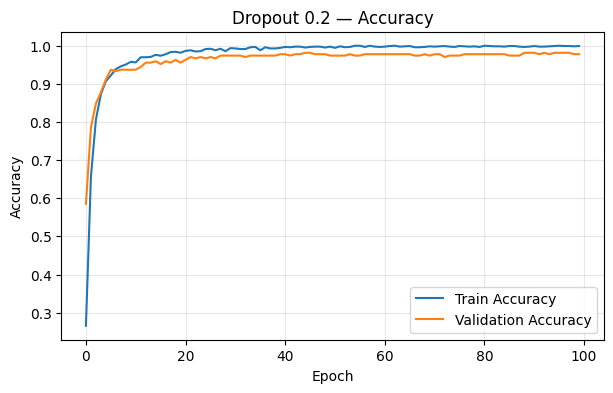

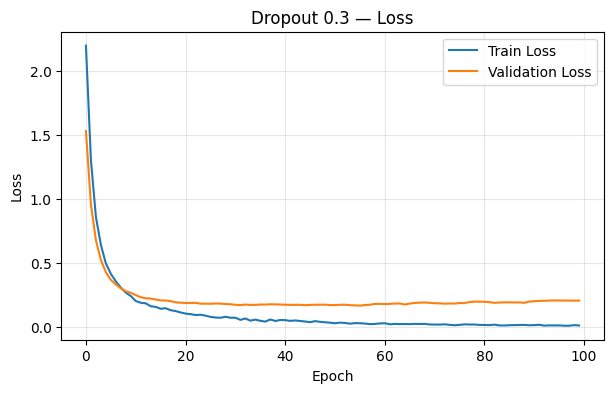

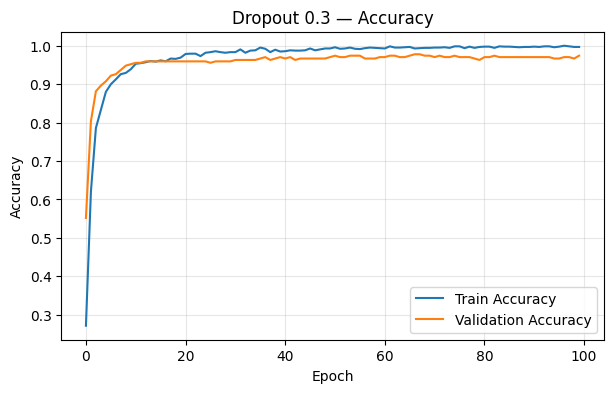

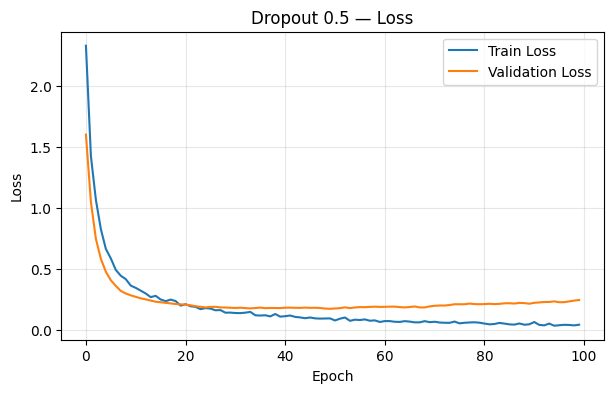

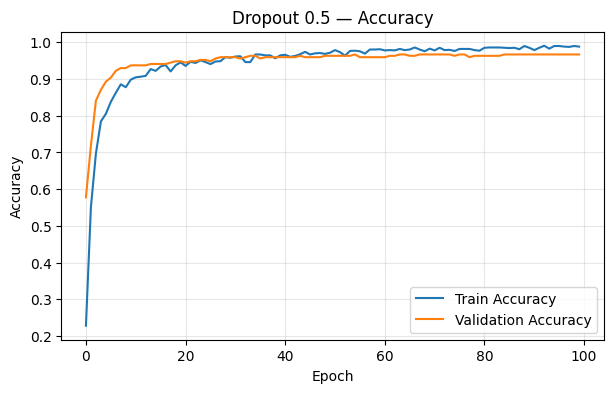

In [38]:
dropout_rates = [0.2, 0.3, 0.5]

dropout_results = {}

for do in dropout_rates:

    model = build_dropout_model(
        input_dim,
        output_units,
        output_activation,
        dropout_rate=do
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    dropout_results[do] = {
        "history": history,
        "best_val_acc": best_val_acc,
        "min_val_loss": min_val_loss
    }

    plot_learning_curves(history, f"Dropout {do}")

In [39]:
for do, result in dropout_results.items():
    print(f"Dropout: {do}")
    print(f"Best Val Accuracy: {result['best_val_acc']:.4f}")
    print(f"Min Val Loss: {result['min_val_loss']:.4f}")
    print("-" * 30)

Dropout: 0.2
Best Val Accuracy: 0.9815
Min Val Loss: 0.1613
------------------------------
Dropout: 0.3
Best Val Accuracy: 0.9778
Min Val Loss: 0.1680
------------------------------
Dropout: 0.5
Best Val Accuracy: 0.9667
Min Val Loss: 0.1757
------------------------------


### Dropout Selection

I selected **Dropout = 0.2** because it achieved the highest validation accuracy among the tested values.

### Batch Normalization

Batch Normalization is inserted after the hidden Dense layer to test its effect on convergence and validation behavior.

In [40]:
def build_batchnorm_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(64),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation("relu"),

        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])

    return model

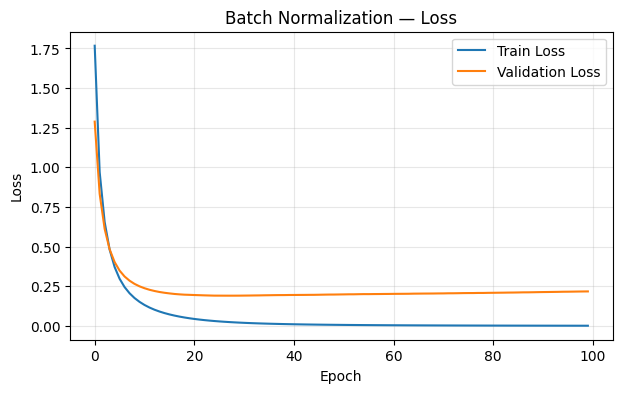

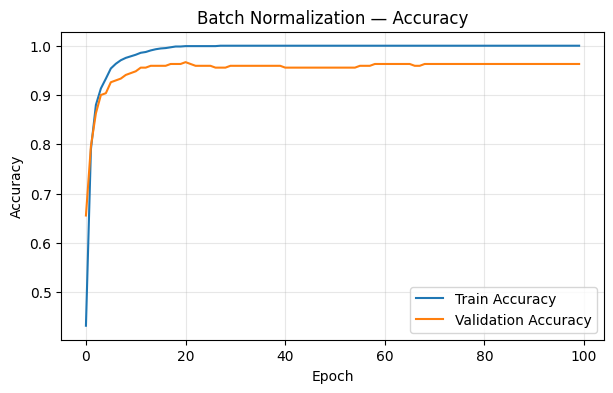

In [41]:
batchnorm_model = build_batchnorm_model(
    input_dim,
    output_units,
    output_activation
)

batchnorm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

history_bn = batchnorm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_learning_curves(history_bn, "Batch Normalization")

#### Batch Normalization Result

Batch Normalization reached **0.9667** best validation accuracy and **0.1906** minimum validation loss. It supported stable training but did not improve on the strongest alternatives.

### L2 Regularization

L2 strengths `1e-4`, `1e-3`, and `1e-2` are compared on the selected architecture.

In [42]:
def build_l2_model(input_dim, output_units, output_activation, l2_rate=0.001):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(l2_rate)
        ),

        tf.keras.layers.Dense(output_units, activation=output_activation)
    ])

    return model

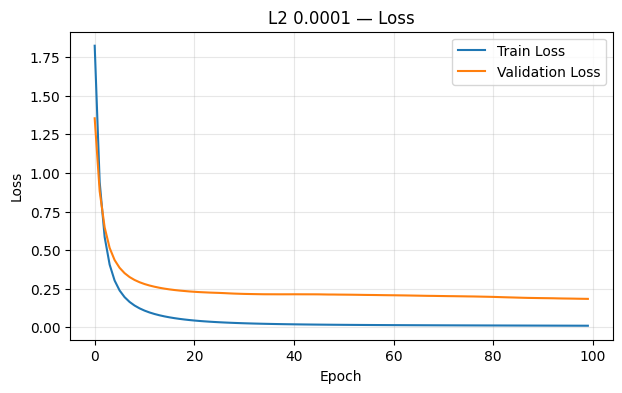

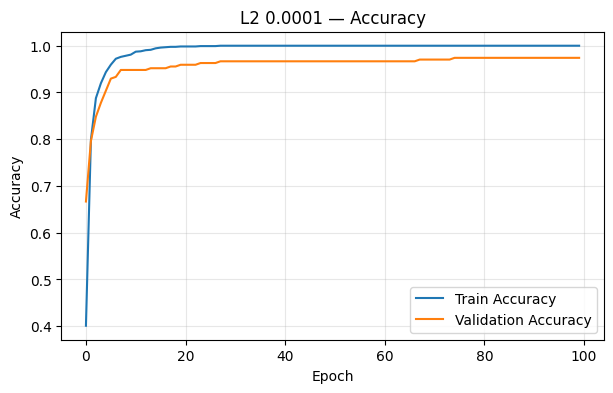

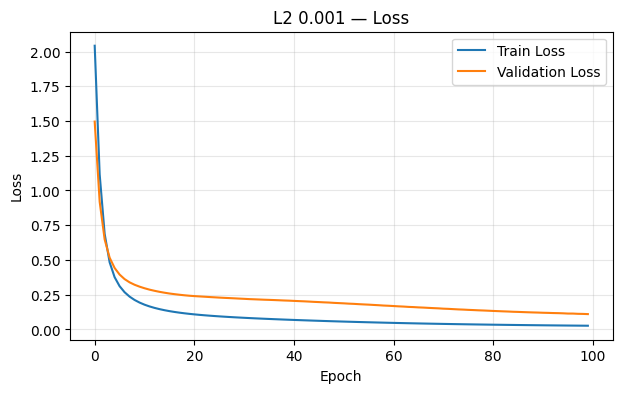

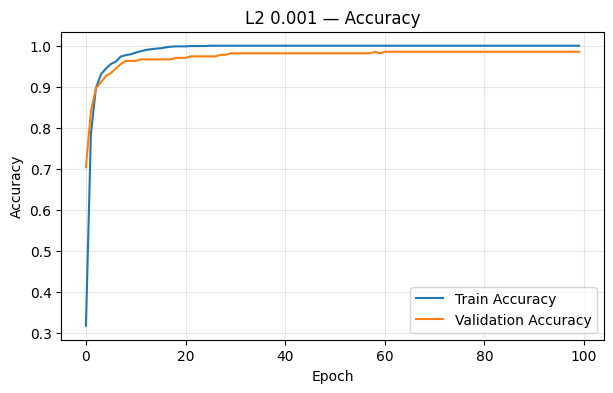

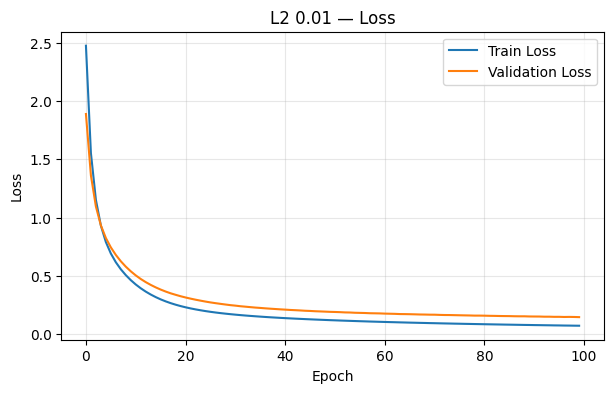

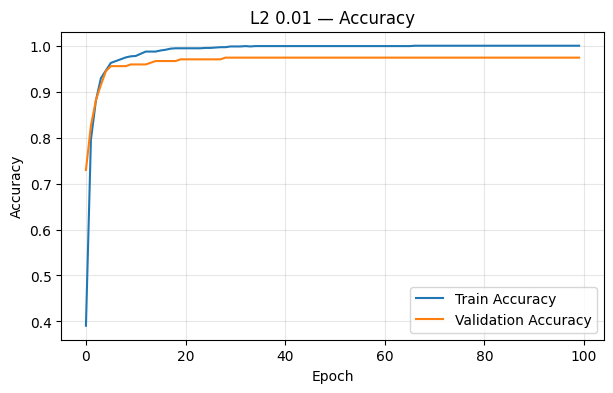

In [43]:
l2_rates = [1e-4, 1e-3, 1e-2]

l2_results = {}

for l2_rate in l2_rates:

    model = build_l2_model(
        input_dim,
        output_units,
        output_activation,
        l2_rate=l2_rate
    )

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss=loss_function,
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    min_val_loss = min(history.history["val_loss"])

    l2_results[l2_rate] = {
        "history": history,
        "best_val_acc": best_val_acc,
        "min_val_loss": min_val_loss
    }

    plot_learning_curves(history, f"L2 {l2_rate}")

### L2 Regularization Selection

I selected **L2 = 0.001** because it achieved the highest validation accuracy and the lowest validation loss among the tested values.

**Selected L2 rate: 0.001**

## Final Optimized Model

The final compact model combines the experimentally selected learning rate (`0.001`), batch size (`32`), Dropout (`0.2`), L2 (`0.001`), and Early Stopping.

In [44]:
def build_final_model(input_dim, output_units, output_activation):
    model = keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_regularizer=keras.regularizers.l2(0.001)
        ),

        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(
            output_units,
            activation=output_activation
        )
    ])

    return model

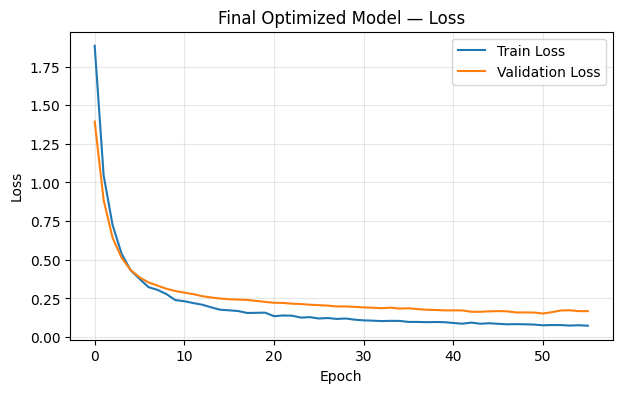

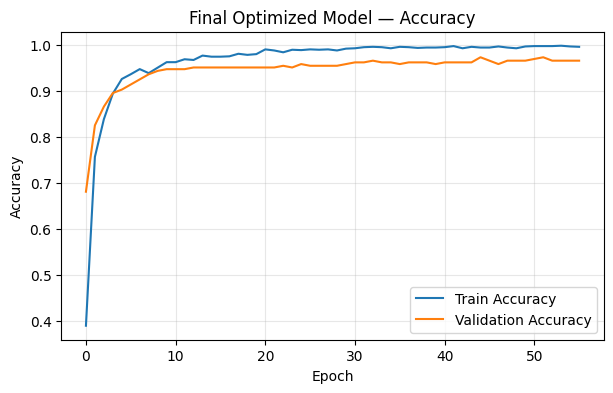

Test Loss: 0.1038
Test Accuracy: 0.9926


In [45]:
final_model = build_final_model(
    input_dim,
    output_units,
    output_activation
)

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=loss_function,
    metrics=["accuracy"]
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

plot_learning_curves(
    final_history,
    "Final Optimized Model"
)

test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## Selected Experiment Summary

The table consolidates the saved results used in the final decision.

In [46]:
experiment_results = pd.DataFrame([
    {
        "Experiment": "Batch Size 32",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Dropout": np.nan,
        "BatchNorm": False,
        "Early Stopping": False,
        "Best Val Accuracy": batch_results[32]["best_val_acc"],
        "Min Val Loss": batch_results[32]["min_val_loss"],
        "Test Accuracy": np.nan
    },

    {
        "Experiment": "Early Stopping",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Dropout": np.nan,
        "BatchNorm": False,
        "Early Stopping": True,
        "Best Val Accuracy": max(history_early.history["val_accuracy"]),
        "Min Val Loss": min(history_early.history["val_loss"]),
        "Test Accuracy": np.nan
    },

    {
        "Experiment": "Dropout 0.2",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Dropout": 0.2,
        "BatchNorm": False,
        "Early Stopping": False,
        "Best Val Accuracy": dropout_results[0.2]["best_val_acc"],
        "Min Val Loss": dropout_results[0.2]["min_val_loss"],
        "Test Accuracy": np.nan
    },

    {
        "Experiment": "Batch Normalization",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Dropout": np.nan,
        "BatchNorm": True,
        "Early Stopping": False,
        "Best Val Accuracy": max(history_bn.history["val_accuracy"]),
        "Min Val Loss": min(history_bn.history["val_loss"]),
        "Test Accuracy": np.nan
    },

    {
        "Experiment": "Final Optimized Model",
        "Learning Rate": 0.001,
        "Batch Size": 32,
        "Dropout": 0.2,
        "BatchNorm": False,
        "Early Stopping": True,
        "Best Val Accuracy": max(final_history.history["val_accuracy"]),
        "Min Val Loss": min(final_history.history["val_loss"]),
        "Test Accuracy": 0.9926
    }
])

experiment_results

,Experiment,Learning Rate,Batch Size,Dropout,BatchNorm,Early Stopping,Best Val Accuracy,Min Val Loss,Test Accuracy
0,Batch Size 32,0.001,32,NaN,False,False,0.970370,0.143183,NaN
1,Early Stopping,0.001,32,NaN,False,True,0.966667,0.148900,NaN
2,Dropout 0.2,0.001,32,0.2,False,False,0.981481,0.161332,NaN
3,Batch Normalization,0.001,32,NaN,True,False,0.966667,0.190601,NaN
4,Final Optimized Model,0.001,32,0.2,False,True,0.974074,0.152213,0.9926


## Conclusions

- The **Medium** network produced the highest best validation accuracy (**0.9778**) and lowest validation loss (**0.1179**) in the architecture comparison.
- The **Shallow** network produced the highest recorded architecture test accuracy (**0.9963**) with the fewest parameters, and was retained as the compact optimization baseline.
- The Deep model increased complexity without improving validation or test performance and showed the clearest overfitting.
- A learning rate of `0.001` and batch size `32` provided stable, strong training behavior.
- Early Stopping avoided unnecessary epochs; Dropout `0.2` was strongest among the tested dropout rates; L2 `0.001` was retained in the final model.
- The final optimized model achieved **0.9926 test accuracy** and **0.1038 test loss**.
